In [3]:
# !pip install nltk pandas scikit-learn gensim

import nltk
from datasets import load_dataset
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
from sklearn.manifold import TSNE
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
nltk.download('punkt')
nltk.download('punkt_tab')

dataset = load_dataset('ag_news', split="train")[:10000]

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Renata\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Renata\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
C:\Users\Renata\miniconda3\envs\pd-26E2\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Renata\.cache\huggingface\hub\datasets--ag_news. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an adm

In [5]:
print("Tokenize os textos")
tokenized_data = [word_tokenize(text.lower()) for text in dataset['text']]

Tokenize os textos


In [6]:
tokenized_data

[['wall',
  'st.',
  'bears',
  'claw',
  'back',
  'into',
  'the',
  'black',
  '(',
  'reuters',
  ')',
  'reuters',
  '-',
  'short-sellers',
  ',',
  'wall',
  'street',
  "'s",
  'dwindling\\band',
  'of',
  'ultra-cynics',
  ',',
  'are',
  'seeing',
  'green',
  'again',
  '.'],
 ['carlyle',
  'looks',
  'toward',
  'commercial',
  'aerospace',
  '(',
  'reuters',
  ')',
  'reuters',
  '-',
  'private',
  'investment',
  'firm',
  'carlyle',
  'group',
  ',',
  '\\which',
  'has',
  'a',
  'reputation',
  'for',
  'making',
  'well-timed',
  'and',
  'occasionally\\controversial',
  'plays',
  'in',
  'the',
  'defense',
  'industry',
  ',',
  'has',
  'quietly',
  'placed\\its',
  'bets',
  'on',
  'another',
  'part',
  'of',
  'the',
  'market',
  '.'],
 ['oil',
  'and',
  'economy',
  'cloud',
  'stocks',
  "'",
  'outlook',
  '(',
  'reuters',
  ')',
  'reuters',
  '-',
  'soaring',
  'crude',
  'prices',
  'plus',
  'worries\\about',
  'the',
  'economy',
  'and',
  'the'

In [7]:
model = Word2Vec(
    sentences=tokenized_data,
    vector_size=100,
    window=5,
    min_count=5,
    workers=2
)

In [8]:
len(model.wv)

7756

In [9]:
model.wv.most_similar("software", topn=5)

[('web', 0.9505407810211182),
 ('services', 0.9321596622467041),
 ('technology', 0.9230712652206421),
 ('business', 0.9205547571182251),
 ('phone', 0.9190224409103394)]

In [10]:
model.wv.most_similar("microsoft", topn=5)

[('service', 0.9298837780952454),
 ('update', 0.9149352312088013),
 ('apple', 0.9126347303390503),
 ('sp2', 0.9095021486282349),
 ('xp', 0.9090994000434875)]

C:\Users\Renata\miniconda3\envs\pd-26E2\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\Renata\miniconda3\envs\pd-26E2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


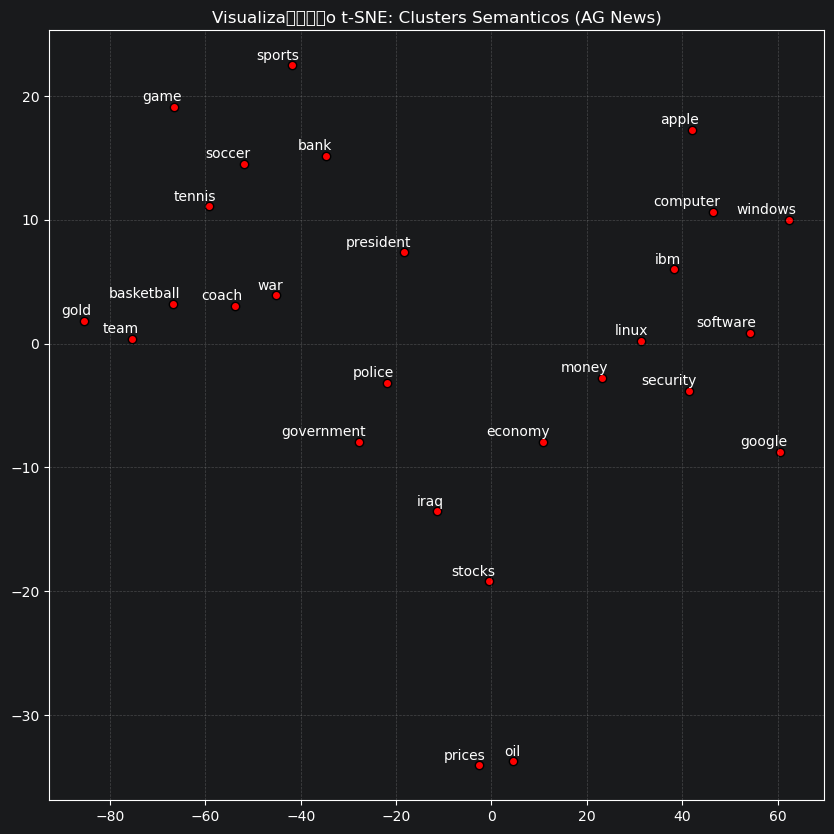

In [11]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np


def plot_words_tsne(model, words):
    valid_words = [w for w in words if w in model.wv]
    word_vectors = np.array([model.wv[word] for word in valid_words])
    tsne = TSNE(n_components=2,
                perplexity=min(5, len(valid_words)-1),
                init='pca',
                random_state=0)
    word_vectors_2d = tsne.fit_transform(word_vectors)

    plt.figure(figsize=(10, 10))
    plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], edgecolors='k', c='r')
    for i, word in enumerate(valid_words):
        plt.annotate(word,
                     xy=(word_vectors_2d[i, 0], word_vectors_2d[i, 1]),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom')
        plt.title("Visualiza﷿﷿﷿﷿o t-SNE: Clusters Semanticos (AG News)")
        plt.grid(True, linestyle='--', alpha=0.3)

palavras_teste = [
    "windows", "linux", "software", "computer", "apple", "ibm", "google",
    "soccer", "basketball", "tennis", "sports", "coach", "game", "team",
    "oil", "gold", "stocks", "economy", "money", "bank", "prices",
    "iraq", "war", "police", "government", "security", "president"
]

plot_words_tsne(model, palavras_teste)

In [12]:
dataset['text']

["Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
 'Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\\which has a reputation for making well-timed and occasionally\\controversial plays in the defense industry, has quietly placed\\its bets on another part of the market.',
 "Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\\about the economy and the outlook for earnings are expected to\\hang over the stock market next week during the depth of the\\summer doldrums.",
 'Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\\flows from the main pipeline in southern Iraq after\\intelligence showed a rebel militia could strike\\infrastructure, an oil official said on Saturday.',
 'Oil prices soar to all-time record, posing new menace to US economy (A